In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [6]:
# Funções para desenhar a animação

def draw_frame(grid):
    rgb_grid = np.zeros((grid.shape[0], grid.shape[1], 3))
    for value, color in color_dict.items():
        rgb_grid[grid == value] = color
    return rgb_grid

def animation(initial_grid, rule, frames=200, interval=100):
    initial_grid = np.array(initial_grid)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.axis("off")
    img = ax.imshow(draw_frame(initial_grid), interpolation="nearest")

    grid = initial_grid
    grid_history = [grid.copy()]

    def update(frame):
        nonlocal grid
        grid = rule(grid)
        grid_history.append(grid.copy())
        img.set_data(draw_frame(grid))
        return img,

    anim = FuncAnimation(fig, update, frames=frames, interval=interval, blit=True)
    plt.close(fig)
    return anim, grid_history

In [7]:
# Constantes de cores

color_dict = {
    0: (1, 1, 1),  # Branco = célula vazia
    1: (0, 1, 0),   # Verde = árvore padrão
    2: (1, 0, 0),  # Vermelho = árvore queimando
    3: (0, 0.4, 1), # Azul = Água (Barreira natural)
    4: (0.3, 0.3, 0.3), # Cinza = Estrada (Barreira artificial)
}

# Regra para alterar grade
def update_grid(grid):
    new_grid = grid.copy()

    rows = len(grid)
    cols = len(grid[0])

    for i in range(rows):
        for j in range(cols):

            # add se eh uma barreira de agua (lago ou rio) o fogo nao se propaga
            if grid[i][j] == 3:
              continue

            # vizinhos
            neighbors = []
            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:
                    if di == 0 and dj == 0:
                      continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < rows and 0 <= nj < cols:
                        neighbors.append(grid[ni][nj])
                    else:
                        neighbors.append(0)
          #arvore tipo padrão
            #regra avore queima
            if grid[i][j] == 1:
              if 2 in neighbors :
                if grid[i][j] == 1:
                  new_grid[i][j] = 2
            elif grid[i][j] == 4: # ADD logica de permeabilidade variavel aplicada nas estradas, onde uma arvore pode continuar pegando fogo por cima, por exemplo
              if 2 in neighbors:
                permeabilidade = 0.1 # 10% de chance de passar pela estrada
                if random.random() < permeabilidade:
                  new_grid[i][j] = 2

            #regra avore some
            if grid[i][j] == 2:
              if(i,j) in pixels_estrada:
                new_grid[i][j] = 4
              else:
                new_grid[i][j] = 0
    return new_grid

# Parâmetros
grid_size = [100, 100]
steps = 300
tree_density = 0.5

# Grade inicial
grid_size = [100, 100]
initial_grid = np.zeros(grid_size, dtype=int)

# Inicialização da grade
for i in range(grid_size[0]):
    for j in range(grid_size[1]):
        if random.random() < tree_density:
            initial_grid[i][j] = 1

# ADD Logica dos rios para uma barreira natural contínua usando a funcao seno para criar as curvas/ondulacoes
amplitude = 10
frequencia = 0.08
centro_rio = grid_size[0] // 3

for j in range(grid_size[1]):
  linha_rio = int(centro_rio + amplitude * math.sin(frequencia * j))
  for espessura in range(-1, 2):
    if 0 <= linha_rio + espessura < grid_size[0]:
      initial_grid[linha_rio + espessura][j] = 3

#ADD Logica das estradas/pontes para uma barreira artificial contínua gerada pela interpolação linear de dois pontos aleatoricamente gerados
coluna_inicio = random.randint(0, grid_size[1]-1)
coluna_fim = random.randint(0, grid_size[1]-1)

inicio = (0, coluna_inicio)
fim = (grid_size[0]-1, coluna_fim)

dist_estrada = int(max(abs(fim[0] - inicio[0]), abs(fim[1] - inicio[1])))
pixels_estrada = [] #add lista que guarda onde a estrada passa

for t in range(dist_estrada + 1):
  l = int(inicio[0] + (fim[0] - inicio[0]) * t / dist_estrada)
  c = int(inicio[1] + (fim[1] - inicio[1]) * t / dist_estrada)

  for dl in range(0, 2):
    for dc in range(0, 2):
      if 0 <= l + dl < grid_size[0] and 0 <= c+dc < grid_size[1]:
        initial_grid[l+dl][c+dc] = 4
        pixels_estrada.append((l+dl, c+dc))

#ADD logica dos lagos, que sao barreiras naturais finitas
lagos_gerados = 0
tentativas = 0

while lagos_gerados < 1 and tentativas < 200:
  tentativas += 1
  centro_lago = (random.randint(60,90), random.randint(10,90))
  raio_base = 12
  margem = raio_base + 6

  colisao = False
  for p_estrada in pixels_estrada:
    dist = math.sqrt((centro_lago[0] - p_estrada[0])**2 + (centro_lago[1]-p_estrada[1])**2 )
    if dist < margem:
      colisao = True
      break
  if colisao: continue

  for i in range(grid_size[0]):
    for j in range(grid_size[1]):
      dist = math.sqrt((i - centro_lago[0])**2 + (j - centro_lago[1])**2)
      ruido = random.uniform(-0.5, 0.5)
      if dist < (raio_base + ruido):
        if initial_grid[i][j] != 4:
          initial_grid[i][j] = 3
  lagos_gerados += 1
# Fogo inicial no centro
i, j = grid_size[0] // 2, grid_size[1] // 2
initial_grid[i][j] = 2

# Linha que cria a animação
anim, grid_history = animation(initial_grid, update_grid, steps, 50)

# Mostra a animação
HTML(anim.to_jshtml())

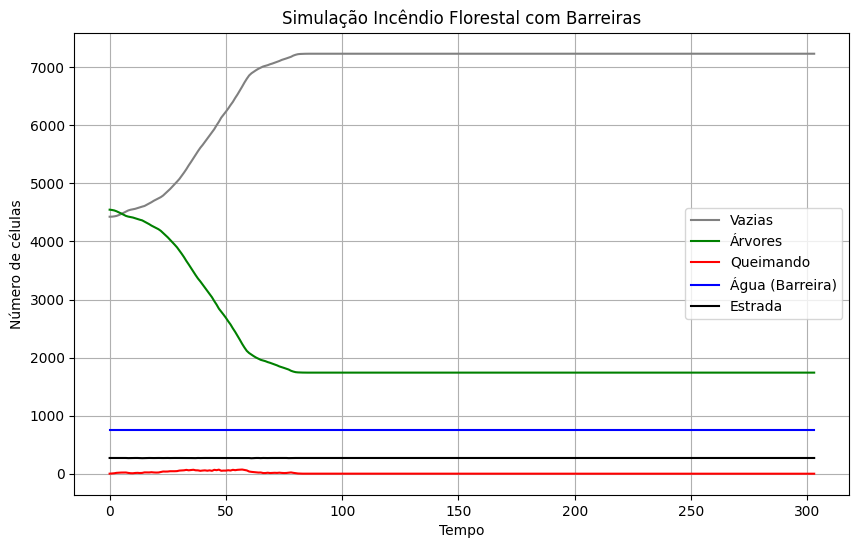

In [8]:
import matplotlib.pyplot as plt


empty_counts = []
tree_counts = []
burning_counts = []
water_counts = []
road_counts = []

for grid in grid_history:
    empty_counts.append((grid == 0).sum())
    tree_counts.append((grid == 1).sum())
    burning_counts.append((grid == 2).sum())
    water_counts.append((grid == 3).sum())
    road_counts.append((grid == 4).sum())



plt.figure(figsize=(10, 6))
plt.plot(empty_counts, label="Vazias", color='grey')
plt.plot(tree_counts, label="Árvores", color='green')
plt.plot(burning_counts, label="Queimando", color ='red')
plt.plot(water_counts, label="Água (Barreira)", color='blue') # Linha da Água
plt.plot(road_counts, label="Estrada", color='black') #linha da estrada
# remove if clima por estar dando erro e não ter outra parte falando disso no codigo

plt.xlabel("Tempo")
plt.ylabel("Número de células")
plt.title("Simulação Incêndio Florestal com Barreiras")
plt.legend()
plt.grid(True)
plt.show()